In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# 1. Load Data (Assuming the Kaggle dataset filename)
df = pd.read_excel('/content/Sample data.xlsx')

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,No-Show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


In [4]:
# 2. Data Cleaning & Feature Engineering
# Convert to datetime objects
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.normalize()
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.normalize()

# Calculate Lead Time (Gap between booking and appointment)
df['LeadTime'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Remove any erroneous data (LeadTime cannot be negative)
df = df[df['LeadTime'] >= 0]

# Encode Target (No-show: 'Yes' = 1, 'No' = 0)
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})


#The "SMS Effectiveness" Bar Plot

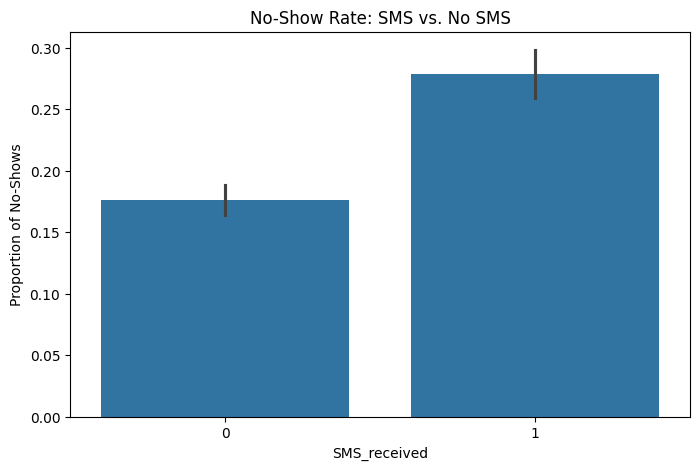

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(x='SMS_received', y='No-show', data=df)
plt.title('No-Show Rate: SMS vs. No SMS')
plt.ylabel('Proportion of No-Shows')
plt.show()

#The "Lead Time" Distribution

/tmp/ipykernel_887/2631203185.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['No-show'] == 0]['LeadTime'], label='Show', shade=True)
/tmp/ipykernel_887/2631203185.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['No-show'] == 1]['LeadTime'], label='No-show', shade=True)


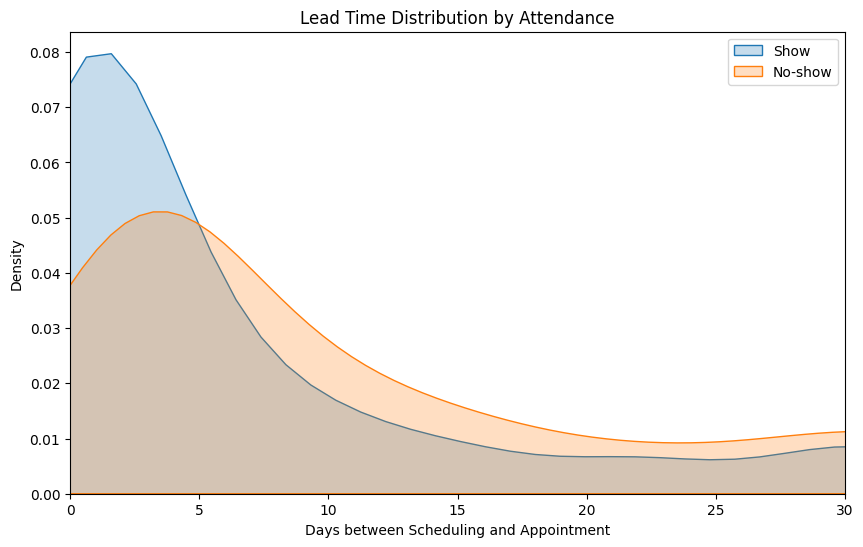

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['No-show'] == 0]['LeadTime'], label='Show', shade=True)
sns.kdeplot(df[df['No-show'] == 1]['LeadTime'], label='No-show', shade=True)
plt.title('Lead Time Distribution by Attendance')
plt.xlabel('Days between Scheduling and Appointment')
plt.xlim(0, 30) # Focus on the first month
plt.legend()

#The "Weekday" Heatmap

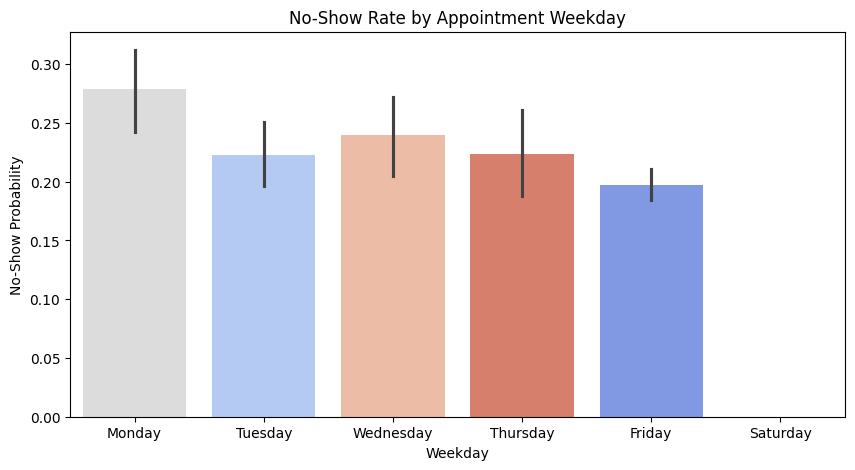

In [14]:
df['Weekday'] = df['AppointmentDay'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
plt.figure(figsize=(10, 5))
sns.barplot(x='Weekday', y='No-show', data=df, order=weekday_order, palette='coolwarm', hue='Weekday', legend=False)
plt.title('No-Show Rate by Appointment Weekday')
plt.ylabel('No-Show Probability')
plt.savefig('weekday_trend.png')

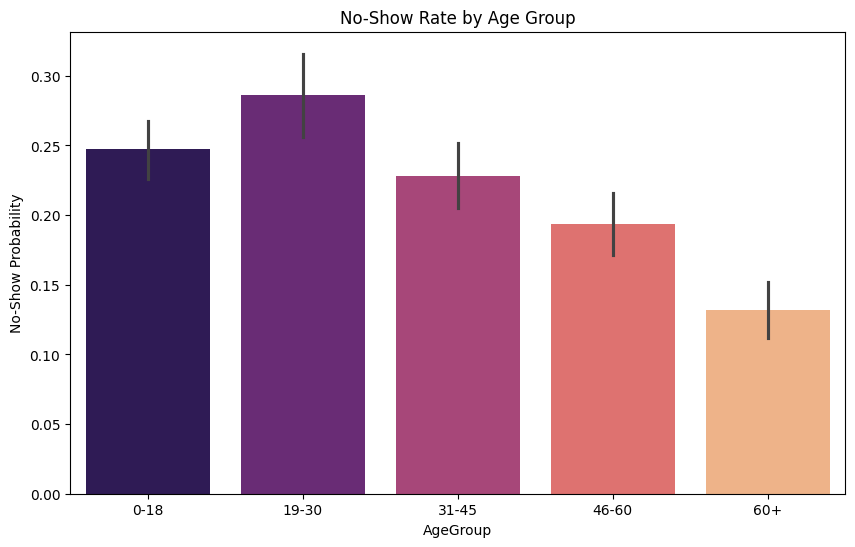

In [11]:
plt.figure(figsize=(10, 6))
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 115],
                        labels=['0-18', '19-30', '31-45', '46-60', '60+'], include_lowest=True)
sns.barplot(x='AgeGroup', y='No-show', data=df, palette='magma', hue='AgeGroup', legend=False)
plt.title('No-Show Rate by Age Group')
plt.ylabel('No-Show Probability')
plt.savefig('age_trend.png')

In [5]:
# 3. Select Features for Model
# Using Age, LeadTime, and SMS_received as starters
features = ['Age', 'LeadTime', 'SMS_received', 'Scholarship', 'Hipertension']
X = df[features]
y = df['No-show']

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Decision Tree
# Use class_weight='balanced' because no-shows are usually the minority class
model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
model.fit(X_train, y_train)

# 6. Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.55      0.68       956
           1       0.30      0.71      0.42       256

    accuracy                           0.59      1212
   macro avg       0.59      0.63      0.55      1212
weighted avg       0.75      0.59      0.62      1212



              precision    recall  f1-score   support

           0       0.88      0.55      0.68       956
           1       0.30      0.71      0.42       256

    accuracy                           0.58      1212
   macro avg       0.59      0.63      0.55      1212
weighted avg       0.75      0.58      0.62      1212



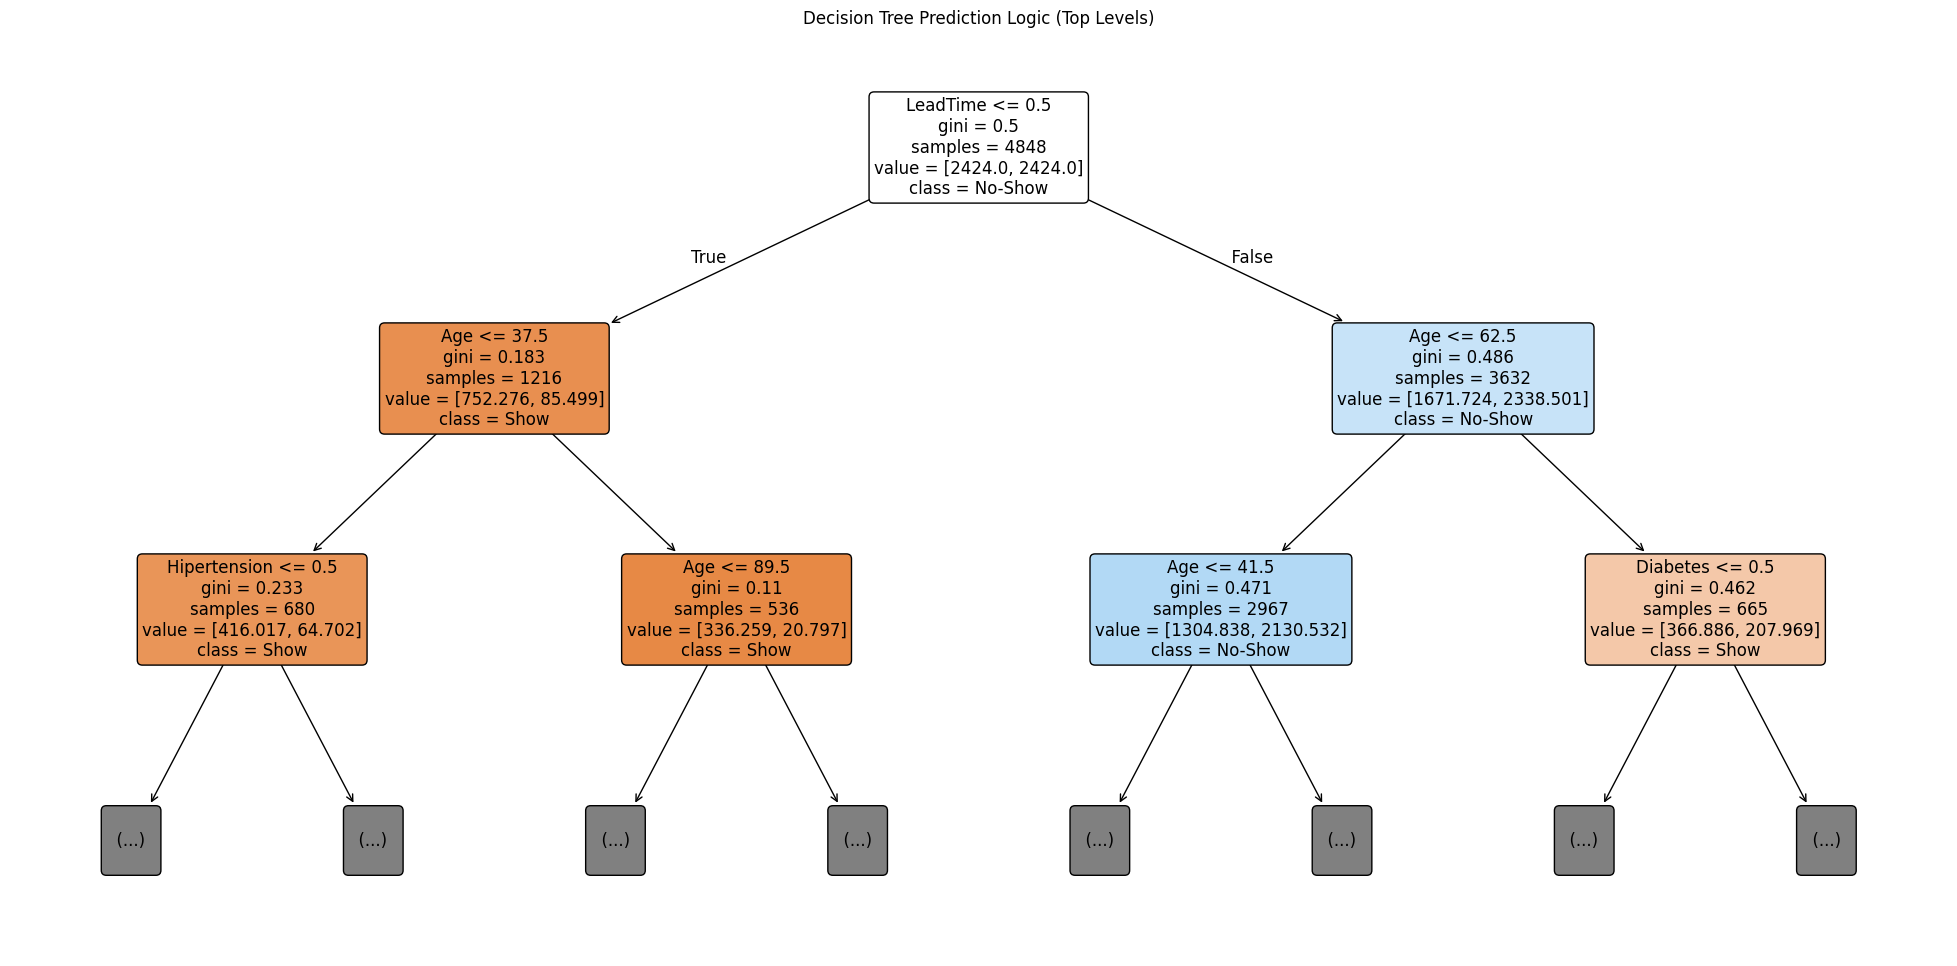

In [15]:
features = ['Age', 'LeadTime', 'SMS_received', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
X = df[features]
y = df['No-show']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model with 'balanced' weight to prioritize catching actual no-shows
dtree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dtree.fit(X_train, y_train)

# 5. Visualizing the Prediction Logic
plt.figure(figsize=(25, 12))
plot_tree(dtree, feature_names=features, class_names=['Show', 'No-Show'],
          filled=True, rounded=True, max_depth=2, fontsize=12)
plt.title("Decision Tree Prediction Logic (Top Levels)")
plt.savefig('decision_tree_logic.png')

# Print Evaluation Metrics
y_pred = dtree.predict(X_test)
print(classification_report(y_test, y_pred))

#NetworkX:

This is the most suitable library for creating and analyzing details, such as mapping relationships between patients, doctors, and appointment slots.

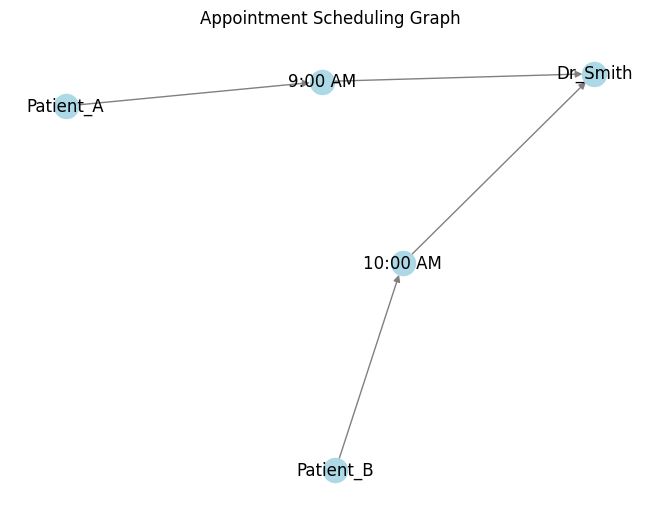

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a Directed Graph
G = nx.DiGraph()

# Add Nodes: Patients, Doctors, and Slots
G.add_node("Patient_A", node_type="patient")
G.add_node("Patient_B", node_type="patient")
G.add_node("Dr_Smith", node_type="doctor")
G.add_node("9:00 AM", node_type="slot")
G.add_node("10:00 AM", node_type="slot")

# Add Edges: Relationships
G.add_edge("Patient_A", "9:00 AM", relationship="books")
G.add_edge("9:00 AM", "Dr_Smith", relationship="with")
G.add_edge("Patient_B", "10:00 AM", relationship="books")
G.add_edge("10:00 AM", "Dr_Smith", relationship="with")

# Visualize the Graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Appointment Scheduling Graph")
plt.show()


Steps for Future Predictions
To predict "future" no-show.

Step 1: Data Preprocessing (Cleaning)
Example: Standardize your columns. If Age has a -1 (a common error in this dataset), remove it. Convert strings like "Yes/No" into "1/0".

Action: df = df[df.Age >= 0]

Step 2: Feature Selection (Choosing the "Signals")
Example: Don't include PatientID or AppointmentID—they are random numbers and will confuse the model. Choose Age, LeadTime, SMS_received, and DayOfWeek.

Step 3: Model Training (The Decision Tree)
Example: Split your data into 80% training (to learn patterns) and 20% testing (to check accuracy).

In [9]:
from sklearn.tree import DecisionTreeClassifier
# max_depth=5 prevents the tree from getting too complex (overfitting)
dtree = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

#Generating the Tree Diagram

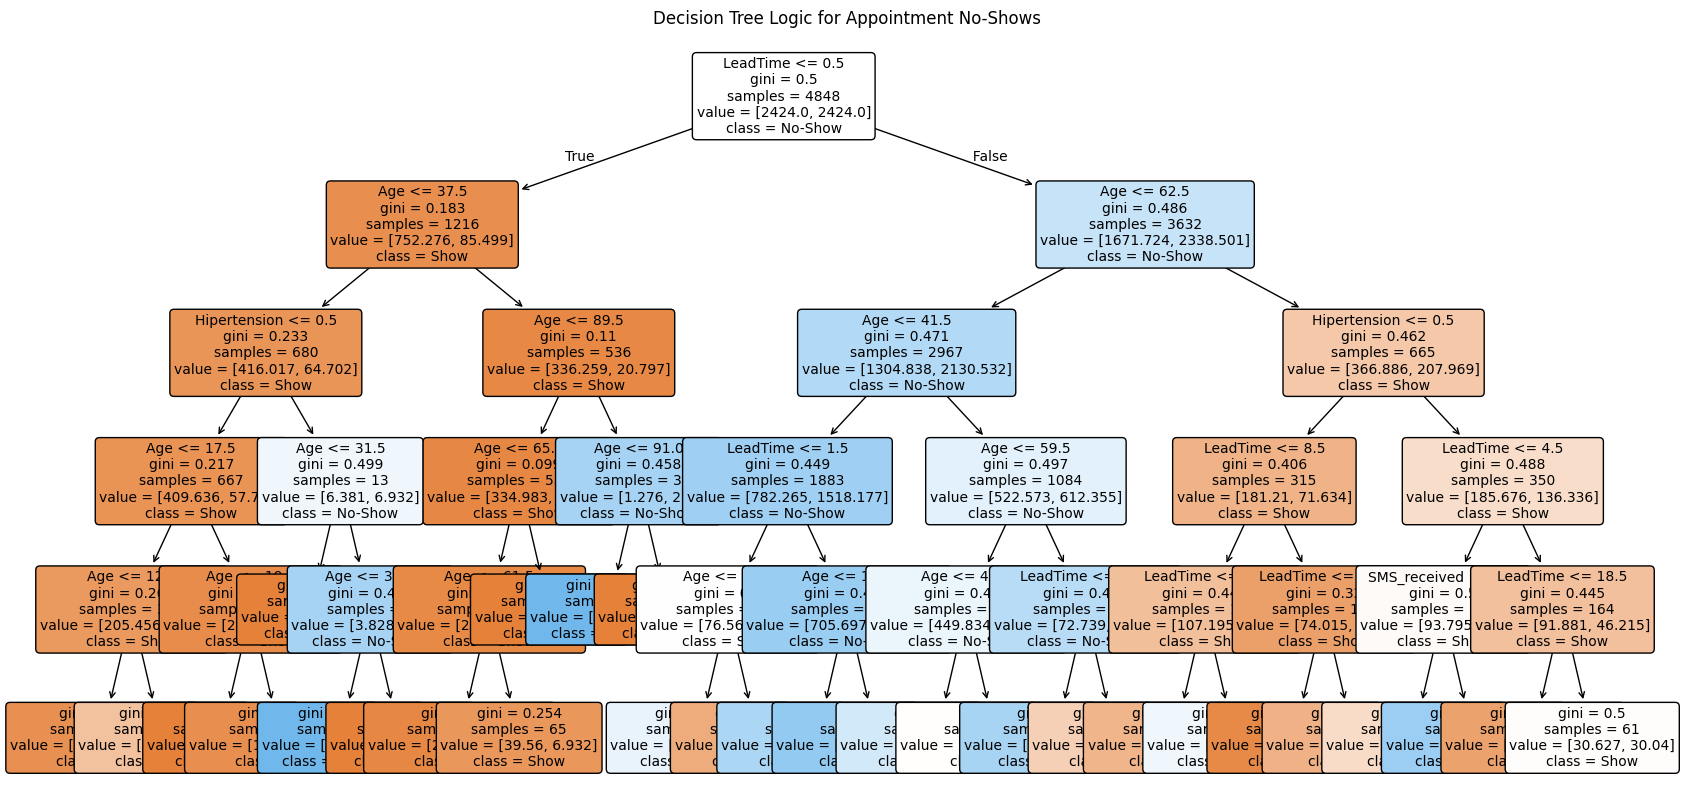

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dtree,
          feature_names=features,
          class_names=['Show', 'No-Show'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Logic for Appointment No-Shows")
plt.show()